# Flu Vaccine Prediction Project: Phase 3
**Author:** [`Sharon Kipruto`]  
**Stakeholder:** Public Health Organizations

## Business Understanding
Influenza is a major public health concern. Vaccination is the most effective way to prevent the flu and reduce the burden on healthcare systems. This project aims to predict whether individuals received the **Seasonal Flu Vaccine** based on demographic data, health behaviors, and personal opinions. By identifying the key factors that drive vaccination, public health officials can design more targeted outreach campaigns.

## Problem Statement
The goal is to build a binary classification model to predict the `seasonal_vaccine` target. 
- **Target:** `seasonal_vaccine` (0 = Not Vaccinated, 1 = Vaccinated).
- **Primary Metric:** **F1-Score and Recall**. We want to minimize "False Negatives" (missing people who were likely to get vaccinated) to ensure public health resources are used efficiently.

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load datasets
features_df = pd.read_csv('DATA/training_set_features.csv')
labels_df = pd.read_csv('DATA/training_set_labels.csv')

# Merge dataframes
df = features_df.merge(labels_df, on='respondent_id')

# Drop columns with >45% missing values (identified in previous analysis)
df.drop(columns=['employment_occupation', 'employment_industry', 'health_insurance'], inplace=True)

# Select Target and Features
X = df.drop(columns=['respondent_id', 'h1n1_vaccine', 'seasonal_vaccine'])
y = df['seasonal_vaccine']

## Exploratory Data Analysis
We will examine the distribution of the target and the impact of a doctor's recommendation, as it is often a high-impact feature.

C:\Users\User\AppData\Local\Temp\ipykernel_24304\895844658.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


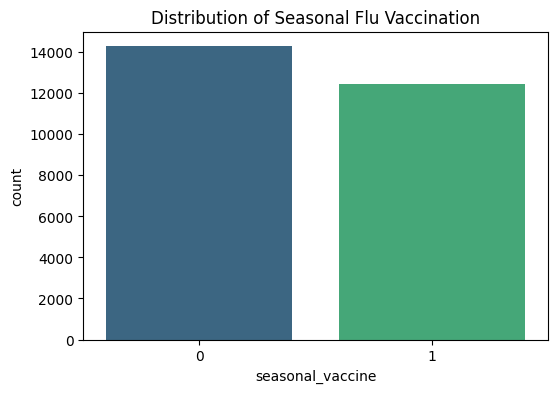

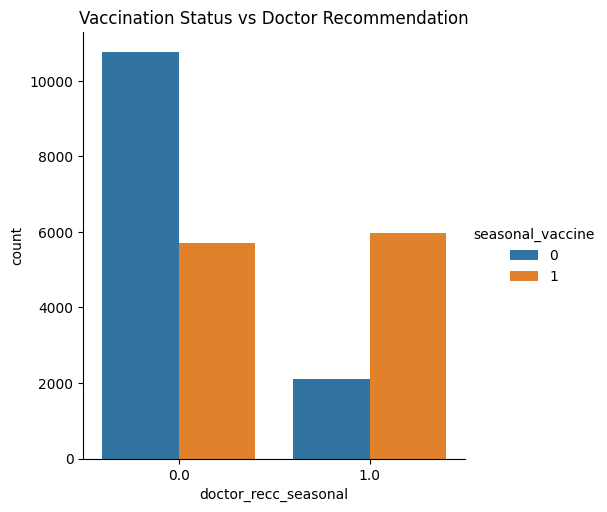

<Figure size 640x480 with 0 Axes>

In [7]:
# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Seasonal Flu Vaccination')
plt.show()

# Relationship between Doctor Recommendation and Vaccination
sns.catplot(x="doctor_recc_seasonal", hue="seasonal_vaccine", data=df, kind="count")
plt.title('Vaccination Status vs Doctor Recommendation')
plt.show()

plt.savefig('./Visualizations/doctor_recommendation_vs_vaccination.png')

In [8]:
#identify column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns

# Preprocessing Pipelines
numeric_transformer=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

#combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [9]:
# Create a modeling pipeline for Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'))
])

# Fit model
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      2891
           1       0.76      0.76      0.76      2451

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



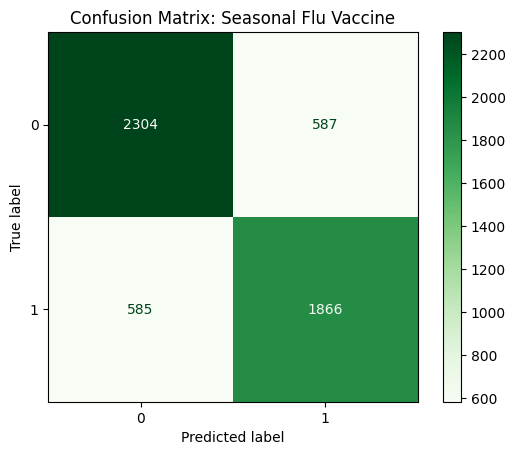

NameError: name 'numeric_features' is not defined

In [10]:
# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Greens')
plt.title('Confusion Matrix: Seasonal Flu Vaccine')
plt.show()

# Extract Feature Importance
importances = rf_model.named_steps['classifier'].feature_importances_
feature_names = numeric_features.tolist() + \
                rf_model.named_steps['preprocessor'].transformers_[1][1]\
                .named_steps['onehot'].get_feature_names_out(categorical_features).tolist()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', color='teal')
plt.title('Top 10 Predictors for Seasonal Flu Vaccine')
plt.show()